#Unidad 1:Fundamentos del Aprendizaje Automatico
##Evaluacion basica de modelos con un ejemplo de productos
###Proposito
En este notebook trabajaremos un solo ejemplo durante toda la practica:una tabla de productos
1.Conocer los datos
2.Calcular medias estadisaticas sencillas
3.Representar los datos con graficas
4.Definir que significa que un producto sea un exito de ventas
5.Comparar la realidad con una prediccion
6.Construir una matriz de confusion
7.Calcular Accuary,Precision y Recall
8.Separar datos para entrenamiento y prueba
9.Aplicar una validacion cruzada sencilla

#0Preparacion del entorno
#Usaremos estas bibliotecas
Numpy:Operaciones Numericas
Pandas:Tablas de datos
Matplotlip:Graficas
Scikit-learn:Metricas y modelos sencillas

#Ejecuta la siguiente celda

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.linear_model import LogisticRegression

np.random.seed(42)

print("Entorno Preparado Correctamente")

Entorno Preparado Correctamente


#Nuestro ejemplo: una tienda de productos
Imaginemos una tienda que registra información de sus productos.

Cada fila representa un producto y contiene:

id_producto : número que identifica al producto;

precio : precio de venta;

stock : cantidad disponible;

calificacion : valoración de los clientes de 1 a 5;

ventas_mes : unidades
vendidas durante el mes.

Primero crearemos una pequeña tabla con datos fáciles de observar.

In [7]:
import pandas as pd

productos = pd.DataFrame({
    "id_producto": list(range(1, 21)),
    "precio": [
        120, 85, 250, 310, 150, 99, 450, 210, 180, 75,
        390, 130, 275, 160, 220, 95, 340, 200, 145, 290
    ],
    "stock": [
        45, 80, 30, 25, 60, 95, 20, 40, 50, 100,
        15, 70, 35, 55, 42, 90, 18, 48, 65, 28
    ],
    "calificacion": [
        4, 3, 5, 4, 4, 3, 5, 4, 4, 2,
        5, 3, 5, 4, 4, 3, 5, 4, 3, 5
    ],
    "ventas_mes": [
        170, 90, 230, 180, 160, 75, 260, 155, 145, 60,
        250, 110, 220, 150, 165, 80, 240, 175, 120, 210
    ]
})

productos

,id_producto,precio,stock,calificacion,ventas_mes
0,1,120,45,4,170
1,2,85,80,3,90
2,3,250,30,5,230
3,4,310,25,4,180
4,5,150,60,4,160
5,6,99,95,3,75
6,7,450,20,5,260
7,8,210,40,4,155
8,9,180,50,4,145
9,10,75,100,2,60


#SELECCIÓN EXPLICITA DE DE ESAS COLUMNAS


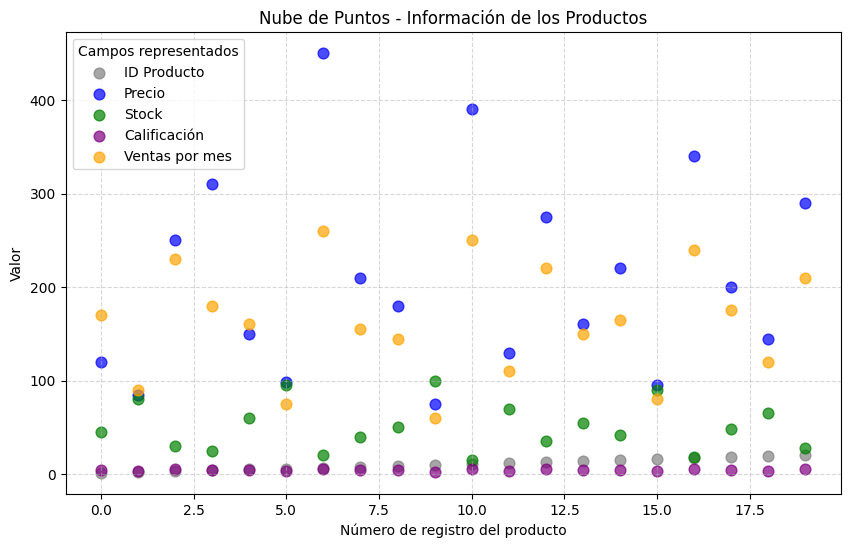

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Campos que queremos representar
campos = [
    'id_producto',
    'precio',
    'stock',
    'calificacion',
    'ventas_mes'
]

# Color para cada campo
colores = {
    'id_producto': 'gray',
    'precio': 'blue',
    'stock': 'green',
    'calificacion': 'purple',
    'ventas_mes': 'orange'
}

# Nombre más descriptivo para mostrar en la gráfica
etiquetas = {
    'id_producto': 'ID Producto',
    'precio': 'Precio',
    'stock': 'Stock',
    'calificacion': 'Calificación',
    'ventas_mes': 'Ventas por mes'
}

for col in campos:
    plt.scatter(
        productos.index,
        productos[col],
        label=etiquetas[col],
        color=colores[col],
        alpha=0.7,
        s=60
    )

plt.title("Nube de Puntos - Información de los Productos")
plt.xlabel("Número de registro del producto")
plt.ylabel("Valor")

plt.legend(
    title="Campos representados",
    loc="upper left"
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()